In [ ]:
# Install required libraries
!pip install -q mlxtend
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

# Load data directly from Yash's GitHub repository
url = 'https://raw.githubusercontent.com/yashy1626/ds_dataset/refs/heads/main/store_data.csv'
dataset = pd.read_csv(url, header=None)

# Convert the dataframe into a list of lists (transactions format)
transactions = []
for i in range(0, len(dataset)):
    transactions.append([str(dataset.values[i,j]) for j in range(0, len(dataset.columns)) if str(dataset.values[i,j]) != 'nan'])

# Encode the transactions into a boolean matrix using TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_ary, columns=te.columns_)

print(f"Data is ready for analysis! Shape after encoding: {df.shape}")

Libraries imported successfully!
Data is ready for analysis! Shape after encoding: (7501, 120)


In [ ]:
#Apriori Algorithm
print("Running Apriori Algorithm...")
frequent_itemsets_ap = apriori(df, min_support=0.01, use_colnames=True)
rules_ap = association_rules(frequent_itemsets_ap, metric="lift", min_threshold=1)

#FP-Growth Algorithm
print("Running FP-Growth Algorithm...")
frequent_itemsets_fp = fpgrowth(df, min_support=0.01, use_colnames=True)
rules_fp = association_rules(frequent_itemsets_fp, metric="lift", min_threshold=1)

print(f"Total rules generated by Apriori: {len(rules_ap)}")
print(f"Total rules generated by FP-Growth: {len(rules_fp)}")

Running Apriori Algorithm...
Running FP-Growth Algorithm...
Total rules generated by Apriori: 406
Total rules generated by FP-Growth: 406


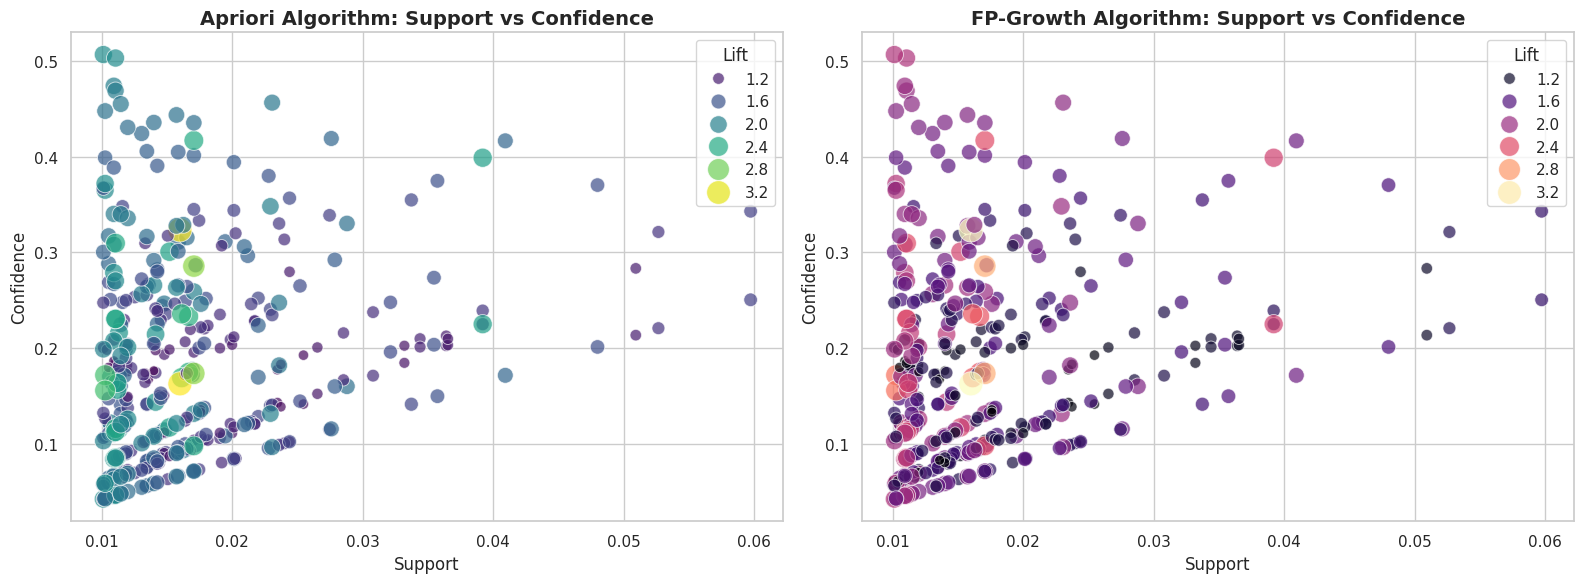


--- Top 10 Strongest Association Rules (Based on Lift) ---


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
215,(herb & pepper),(ground beef),0.049460,0.098254,0.015998,0.323450,3.291994,1.0,0.011138,1.332860,0.732460,0.121457,0.249734,0.243136
214,(ground beef),(herb & pepper),0.098254,0.049460,0.015998,0.162822,3.291994,1.0,0.011138,1.135410,0.772094,0.121457,0.119261,0.243136
386,(ground beef),"(mineral water, spaghetti)",0.098254,0.059725,0.017064,0.173677,2.907928,1.0,0.011196,1.137902,0.727602,0.121097,0.121190,0.229696
383,"(mineral water, spaghetti)",(ground beef),0.059725,0.098254,0.017064,0.285714,2.907928,1.0,0.011196,1.262445,0.697788,0.121097,0.207886,0.229696
398,(olive oil),"(mineral water, spaghetti)",0.065858,0.059725,0.010265,0.155870,2.609786,1.0,0.006332,1.113898,0.660314,0.089017,0.102252,0.163873
395,"(mineral water, spaghetti)",(olive oil),0.059725,0.065858,0.010265,0.171875,2.609786,1.0,0.006332,1.128021,0.656007,0.089017,0.113491,0.163873
193,(tomatoes),(frozen vegetables),0.068391,0.095321,0.016131,0.235867,2.474464,1.0,0.009612,1.183930,0.639616,0.109304,0.155355,0.202549
192,(frozen vegetables),(tomatoes),0.095321,0.068391,0.016131,0.169231,2.474464,1.0,0.009612,1.121381,0.658656,0.109304,0.108243,0.202549
189,(shrimp),(frozen vegetables),0.071457,0.095321,0.016664,0.233209,2.446574,1.0,0.009853,1.179825,0.636767,0.111012,0.152417,0.204017
188,(frozen vegetables),(shrimp),0.095321,0.071457,0.016664,0.174825,2.446574,1.0,0.009853,1.125268,0.653563,0.111012,0.111323,0.204017


In [ ]:
# Set the plot style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Apriori Rules Visualization
sns.scatterplot(
    ax=axes[0], x='support', y='confidence', size='lift', hue='lift',
    data=rules_ap, palette='viridis', sizes=(50, 300), alpha=0.7
)
axes[0].set_title('Apriori Algorithm: Support vs Confidence', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Confidence')
axes[0].legend(title='Lift', loc='upper right')

# Plot 2: FP-Growth Rules Visualization
sns.scatterplot(
    ax=axes[1], x='support', y='confidence', size='lift', hue='lift',
    data=rules_fp, palette='magma', sizes=(50, 300), alpha=0.7
)
axes[1].set_title('FP-Growth Algorithm: Support vs Confidence', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Support')
axes[1].set_ylabel('Confidence')
axes[1].legend(title='Lift', loc='upper right')

plt.tight_layout()
plt.show()

# Display the Top 10 Rules (Sorting by Lift to find the strongest associations)
print("\n--- Top 10 Strongest Association Rules (Based on Lift) ---")
display(rules_ap.sort_values('lift', ascending=False).head(10))